In [75]:
import sys
sys.path.append("../")
import numpy as np

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.icp2D_localization_kalman_tb import icp2DLocalizationKalmanTB
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman

In [76]:
#setup the datasets
dataset = radnavDS(
    dataset_path="/data/radnav/athena/athena_test_2/",
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

#load the map
map_handler = MapHandler(
    maps_folder="/data/radnav/maps",
    map_file="athena.yaml"
)

found 284 radar samples
found 284 lidar samples
found 284 camera samples
found 284 imu (orientation only) samples
found 284imu (full data) samples
found 284 vehicle velocity samples
loaded map from /data/radnav/maps/athena.yaml


In [77]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.3,#originally 0.5
    icp_best_points_percentile=40,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #originally 5
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.6,
    icp_best_points_percentile=50,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

loaded map with 625 points
loaded map with 625 points
gt icp estimated heading:-1.2720800529317324 deg, pose:[-0.02594576  0.0252684 ]
radar icp estimated heading:-1.7849886552634622 deg, pose:[-0.12808117  0.07117748]


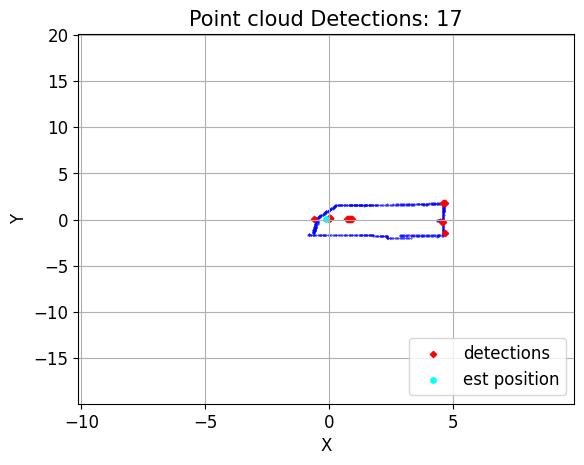

In [78]:
#initialize the test bench
test_bench = icp2DLocalizationKalmanTB(
    localizer=radar_odometry,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset
)

start_heading = np.deg2rad(0)
start_pose = np.array([0.0,0.0])

new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=np.deg2rad(0),
    est_start_pose_m=np.array([0.0,0.0]),
    show=True
)

In [79]:
#initialize the kalman filter
start_time_s = test_bench.get_dataset_start_time(idx=0)
print("dataset start time: {}s".format(start_time_s))

test_bench.init_filter(
    est_start_heading_rad=new_heading_rad,
    est_start_position_m=new_pose_m,
    start_time_s=start_time_s
)

dataset start time: 1713997659.3721128s


In [80]:
lidar_cloud = dataset.get_lidar_point_cloud(idx=0)
radar_cloud = dataset.get_radar_detections(idx=0)

print("radar: {}, lidar:{}".format(radar_cloud.shape[0],lidar_cloud.shape[0]))

radar: 17, lidar:6717


In [81]:
test_bench.run()

  0%|          | 0/284 [00:00<?, ?it/s]

  6%|▋         | 18/284 [00:00<00:03, 70.47it/s]

frame 17 is bad, (imu: 0,data: 1)


 19%|█▊        | 53/284 [00:02<00:12, 19.24it/s]

frame 49 is bad, (imu: 14,data: 15)


...

 83%|████████▎ | 236/284 [00:15<00:03, 13.06it/s]

frame 234 is bad, (imu: 4,data: 5)


 92%|█████████▏| 262/284 [00:16<00:01, 14.91it/s]

frame 260 is bad, (imu: 0,data: 1)


100%|██████████| 284/284 [00:18<00:00, 15.56it/s]


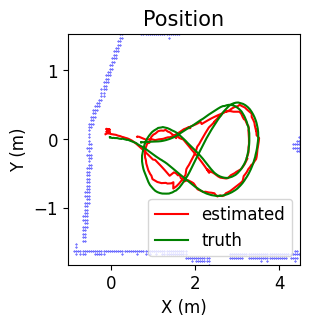

In [82]:
test_bench.plotter.plot_position_history_m(
    history_position_m=test_bench.history_position_m,
    history_position_m_gt=test_bench.history_position_m_gt,
    idx=0,
    ax=None,
    show=True
)

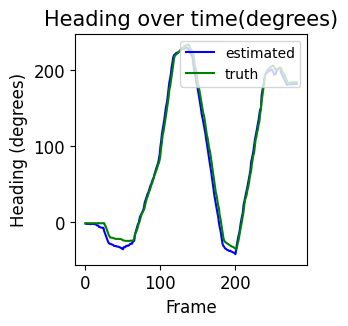

In [83]:
test_bench.plotter.plot_heading_history_deg(
    history_heading_deg=test_bench.history_heading_deg,
    history_heading_deg_gt=test_bench.history_heading_deg_gt,
    idx =0,
    ax=None,
    show=True
)

In [84]:
test_bench.analyze()

,Metric,Euclidian,x,y,phi
0,Mean,0.100012,0.020484,-0.012760,-0.050409
1,Variance,0.002787,0.005563,0.006644,0.016570
2,Median,0.096631,0.008723,-0.003997,-0.042411
3,0.9th percentile,0.175576,0.121254,0.128064,0.216332


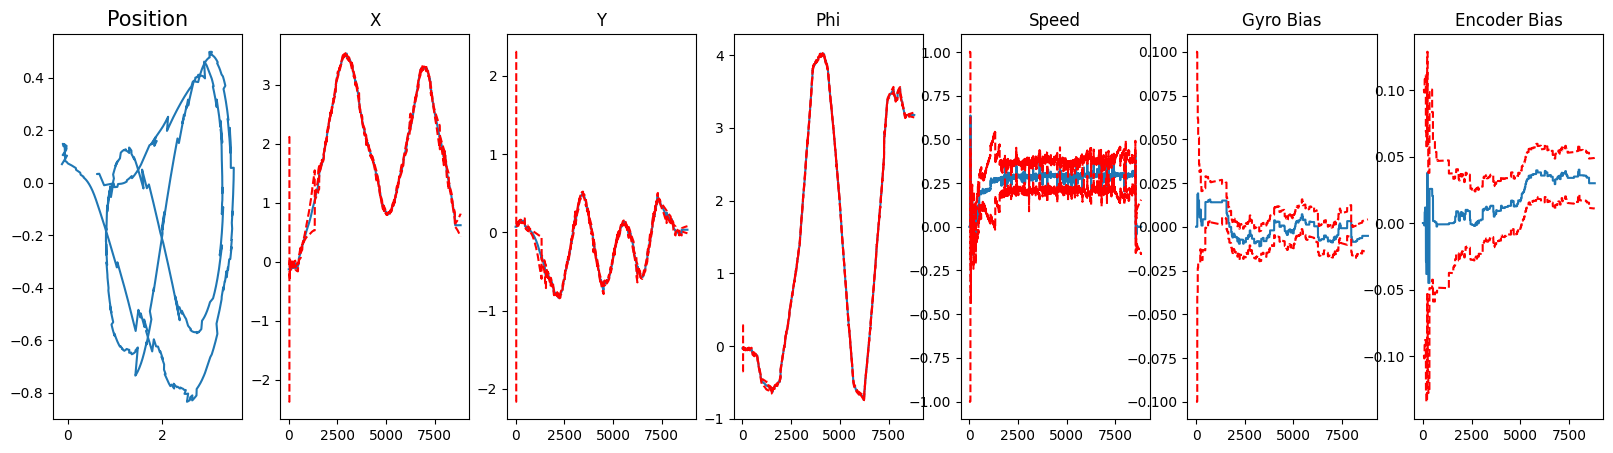

In [85]:
#plot kalman state history
kalman_plotter = PlotterKalman()

kalman_plotter.plot_kalman_result_history(
    x_history=np.array(test_bench.history_filter_est),
    p_history=np.array(test_bench.history_filter_p),
    idx=0
)

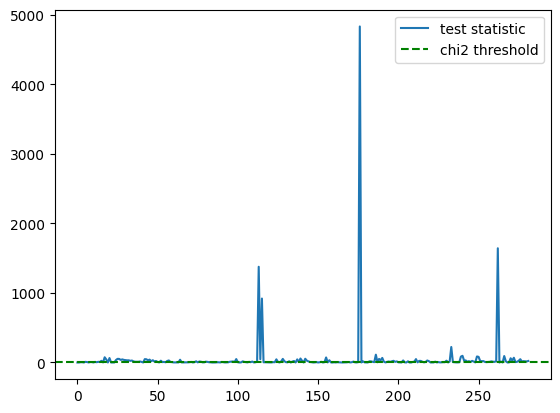

In [86]:
kalman_plotter.plot_chi_2_resp(
    g_thresh=test_bench.filter.g_thresh[2],
    g_hist=np.array(test_bench.history_filter_g),
    idx=0
)

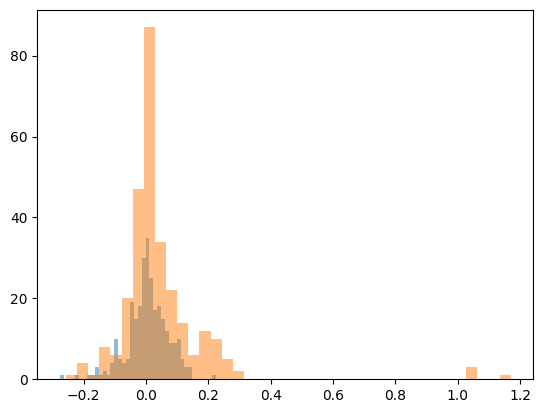

In [87]:
kalman_plotter.plot_residual_hist(
    y_hist=test_bench.history_filter_y,
    idx=0
)

In [88]:
#look at the vehicle velocity data
vel_data = dataset.get_vehicle_vel_data(idx=0)

for i in range(vel_data.shape[0]):

    out_str = "sample: {}, time: {:.2f}s, lin_vel: {:.2f}m/s, ang_vel: {:.2f}rad/s".format(
        i,
        vel_data[i,0],
        vel_data[i,1],
        vel_data[i,2]
    )

    print(out_str)

sample: 0, time: 1713997659.37s, lin_vel: 0.00m/s, ang_vel: 0.00rad/s
sample: 1, time: 1713997659.38s, lin_vel: 0.00m/s, ang_vel: 0.00rad/s
sample: 2, time: 1713997659.39s, lin_vel: 0.00m/s, ang_vel: 0.00rad/s
sample: 3, time: 1713997659.39s, lin_vel: 0.00m/s, ang_vel: 0.00rad/s
sample: 4, time: 1713997659.41s, lin_vel: 0.00m/s, ang_vel: 0.00rad/s
sample: 5, time: 1713997659.41s, lin_vel: 0.00m/s, ang_vel: 0.00rad/s
sample: 6, time: 1713997659.42s, lin_vel: 0.00m/s, ang_vel: 0.00rad/s
sample: 7, time: 1713997659.45s, lin_vel: 0.00m/s, ang_vel: 0.00rad/s
sample: 8, time: 1713997659.45s, lin_vel: 0.00m/s, ang_vel: 0.00rad/s
sample: 9, time: 1713997659.46s, lin_vel: 0.00m/s, ang_vel: 0.00rad/s
sample: 10, time: 1713997659.46s, lin_vel: 0.00m/s, ang_vel: 0.00rad/s
sample: 11, time: 1713997659.47s, lin_vel: 0.00m/s, ang_vel: 0.00rad/s
sample: 12, time: 1713997659.47s, lin_vel: 0.00m/s, ang_vel: 0.00rad/s
sample: 13, time: 1713997659.48s, lin_vel: 0.00m/s, ang_vel: 0.00rad/s
sample: 14, time

In [89]:
# look at the imu raw data
imu_data_full = dataset.get_imu_full_data(idx=0)

for i in range(imu_data_full.shape[0]):

    out_str = "idx: {}, time: {:.2f}s, gyro:[{:.2f},{:.2f},{:.2f}] rad/s, acc: [{:.2f},{:.2f},{:.2f}]".format(
        i,
        imu_data_full[i,0],
        imu_data_full[i,1],
        imu_data_full[i,2],
        imu_data_full[i,3],
        imu_data_full[i,4],
        imu_data_full[i,5],
        imu_data_full[i,6]
    )

    print(out_str)

idx: 0, time: 1713997659.37s, gyro:[-0.01,-0.03,-0.01] rad/s, acc: [-0.02,0.12,9.75]
idx: 1, time: 1713997659.38s, gyro:[0.01,-0.00,-0.00] rad/s, acc: [-0.04,0.19,9.82]
idx: 2, time: 1713997659.39s, gyro:[0.01,0.00,-0.02] rad/s, acc: [-0.01,0.14,9.77]
idx: 3, time: 1713997659.39s, gyro:[0.01,0.00,-0.02] rad/s, acc: [-0.01,0.14,9.77]
idx: 4, time: 1713997659.41s, gyro:[-0.00,-0.01,-0.01] rad/s, acc: [-0.02,0.15,9.80]
idx: 5, time: 1713997659.41s, gyro:[-0.00,-0.01,-0.01] rad/s, acc: [-0.02,0.15,9.80]
idx: 6, time: 1713997659.42s, gyro:[-0.00,-0.00,-0.00] rad/s, acc: [0.01,0.12,9.87]
idx: 7, time: 1713997659.45s, gyro:[0.01,0.02,-0.00] rad/s, acc: [0.00,0.05,9.87]
idx: 8, time: 1713997659.45s, gyro:[0.01,0.02,-0.00] rad/s, acc: [0.00,0.05,9.87]
idx: 9, time: 1713997659.46s, gyro:[0.00,0.01,-0.01] rad/s, acc: [0.02,0.04,9.78]
idx: 10, time: 1713997659.46s, gyro:[0.00,0.01,0.01] rad/s, acc: [-0.10,0.16,9.84]
idx: 11, time: 1713997659.47s, gyro:[0.00,-0.00,-0.02] rad/s, acc: [-0.04,0.14,9.7